In [8]:
# (a)
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_gaussian_kernel(size, sigma):
    # Create a coordinate grid from -(size//2) to +(size//2)
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    
    # Calculate Gaussian
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    
    # Normalize
    return kernel / np.sum(kernel)

kernel = get_gaussian_kernel(5, 2)
print("Normalized Gaussian Kernel")
print(kernel)

Normalized Gaussian Kernel
[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


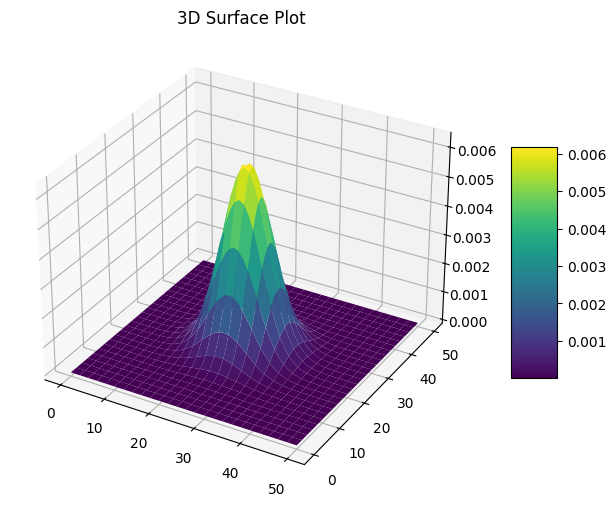

In [7]:
# (b)

size_large = 51
sigma_large = 5
kernel = get_gaussian_kernel(size_large, sigma_large)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

x = np.arange(0, size_large)
y = np.arange(0, size_large)
X, Y = np.meshgrid(x, y)

surf = ax.plot_surface(X, Y, kernel, cmap='viridis', edgecolor='none')
ax.set_title('3D Surface Plot')
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

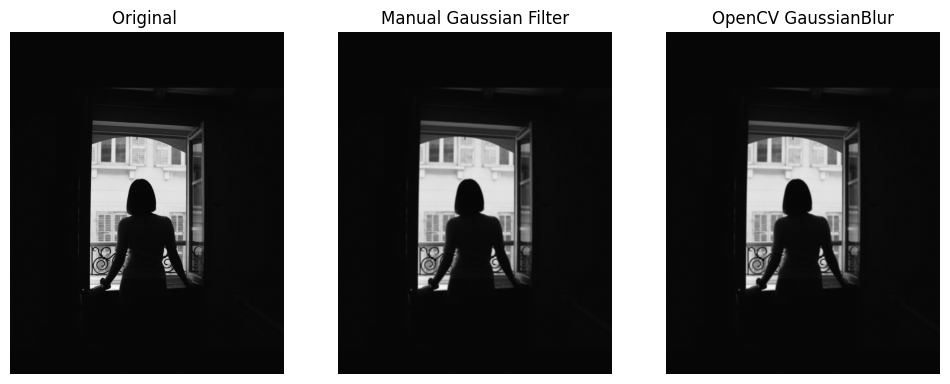

In [13]:
# (c)

im = cv.imread('images/woman_in_shadow.avif', cv.IMREAD_GRAYSCALE)
assert im is not None, 'Image not found'

img_manual = cv.filter2D(im, -1, kernel)

# (d) Using OpenCV's built-in function
img_opencv = cv.GaussianBlur(im, (5, 5), 2)

# Comparison Visualization
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original ')

ax[1].imshow(img_manual, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Manual Gaussian Filter')

ax[2].imshow(img_opencv, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('OpenCV GaussianBlur')

for a in ax: 
    a.axis('off')
    
plt.show()